<a href="https://colab.research.google.com/github/jeevaprakash-S/24ADI003_24BAD048/blob/main/ML_exp2_scenario_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc
)
print("Jeevaprakash_24BAD048")


Jeevaprakash_24BAD048


In [2]:
df = pd.read_csv("LIC.csv")
df.head()


,date,open,high,low,close,volume
0,2022-05-17 09:35:00+05:30,872.00,872.00,872.0,872.00,3759243
1,2022-05-17 09:45:00+05:30,872.00,872.00,872.0,872.00,0
2,2022-05-17 09:55:00+05:30,872.00,918.10,862.0,902.80,12449251
3,2022-05-17 10:05:00+05:30,902.45,908.95,896.0,902.15,5237329
4,2022-05-17 10:15:00+05:30,902.30,905.00,900.0,903.85,1820317


In [8]:
df['Price_Movement'] = np.where(
    df['close'] > df['open'], 1, 0
)


In [9]:
features = ['open', 'high', 'low', 'volume']
target = 'Price_Movement'

X = df[features]
y = df[target]


In [10]:
X = X.fillna(X.median())


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [14]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


In [15]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-Score :", f1_score(y_test, y_pred))


Accuracy : 0.5888738127544098
Precision: 1.0
Recall   : 0.013029315960912053
F1-Score : 0.02572347266881029


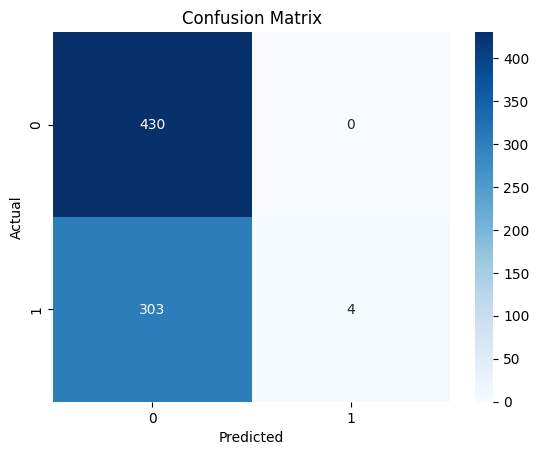

In [16]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


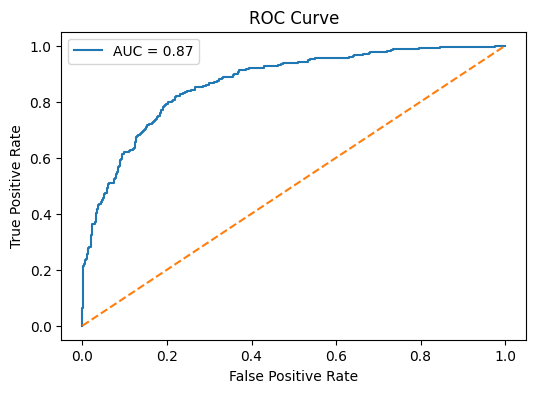

In [18]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


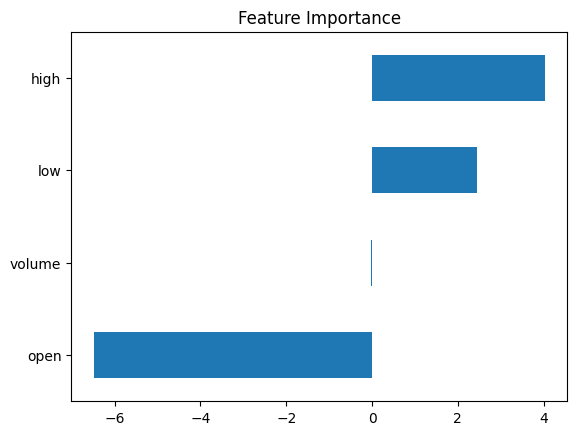

In [19]:
feature_importance = pd.Series(
    model.coef_[0], index=features
)

feature_importance.sort_values().plot(
    kind='barh', title="Feature Importance"
)
plt.show()


In [22]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring="f1"
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
y_best_pred = best_model.predict(X_test)

print("Optimized Accuracy :", accuracy_score(y_test, y_best_pred))
print("Optimized Precision:", precision_score(y_test, y_best_pred, zero_division=0))
print("Optimized Recall   :", recall_score(y_test, y_best_pred, zero_division=0))
print("Optimized F1 Score :", f1_score(y_test, y_best_pred, zero_division=0))

Optimized Accuracy : 0.7964721845318861
Optimized Precision: 0.8127490039840638
Optimized Recall   : 0.6644951140065146
Optimized F1 Score : 0.7311827956989247
